Used libraries

In [67]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
%pip install xlrd  # Install xlrd to read Excel files

Note: you may need to restart the kernel to use updated packages.


ERROR: Invalid requirement: '#': Expected package name at the start of dependency specifier
    #
    ^


Showing Dataset Information

In [68]:
df = pd.read_excel('default of credit card clients.xls')
print(df.head())

  Unnamed: 0         X1   X2         X3        X4   X5     X6     X7     X8  \
0         ID  LIMIT_BAL  SEX  EDUCATION  MARRIAGE  AGE  PAY_0  PAY_2  PAY_3   
1          1      20000    2          2         1   24      2      2     -1   
2          2     120000    2          2         2   26     -1      2      0   
3          3      90000    2          2         2   34      0      0      0   
4          4      50000    2          2         1   37      0      0      0   

      X9  ...        X15        X16        X17       X18       X19       X20  \
0  PAY_4  ...  BILL_AMT4  BILL_AMT5  BILL_AMT6  PAY_AMT1  PAY_AMT2  PAY_AMT3   
1     -1  ...          0          0          0         0       689         0   
2      0  ...       3272       3455       3261         0      1000      1000   
3      0  ...      14331      14948      15549      1518      1500      1000   
4      0  ...      28314      28959      29547      2000      2019      1200   

        X21       X22       X23             

Data Cleaning

In [69]:
df.iloc[0]

Unnamed: 0                            ID
X1                             LIMIT_BAL
X2                                   SEX
X3                             EDUCATION
X4                              MARRIAGE
X5                                   AGE
X6                                 PAY_0
X7                                 PAY_2
X8                                 PAY_3
X9                                 PAY_4
X10                                PAY_5
X11                                PAY_6
X12                            BILL_AMT1
X13                            BILL_AMT2
X14                            BILL_AMT3
X15                            BILL_AMT4
X16                            BILL_AMT5
X17                            BILL_AMT6
X18                             PAY_AMT1
X19                             PAY_AMT2
X20                             PAY_AMT3
X21                             PAY_AMT4
X22                             PAY_AMT5
X23                             PAY_AMT6
Y             de

In [70]:

df = df.apply(pd.to_numeric, errors='coerce')      #Convert all Object values to float64 values
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 30001 entries, 0 to 30000
Data columns (total 25 columns):
 #   Column      Non-Null Count  Dtype  
---  ------      --------------  -----  
 0   Unnamed: 0  30000 non-null  float64
 1   X1          30000 non-null  float64
 2   X2          30000 non-null  float64
 3   X3          30000 non-null  float64
 4   X4          30000 non-null  float64
 5   X5          30000 non-null  float64
 6   X6          30000 non-null  float64
 7   X7          30000 non-null  float64
 8   X8          30000 non-null  float64
 9   X9          30000 non-null  float64
 10  X10         30000 non-null  float64
 11  X11         30000 non-null  float64
 12  X12         30000 non-null  float64
 13  X13         30000 non-null  float64
 14  X14         30000 non-null  float64
 15  X15         30000 non-null  float64
 16  X16         30000 non-null  float64
 17  X17         30000 non-null  float64
 18  X18         30000 non-null  float64
 19  X19         30000 non-nul

In [71]:
df.duplicated().sum()       #No duplicate data

np.int64(0)

In [72]:
df=df.drop(index=0,columns="Unnamed: 0")    #delete first row in data & the unnamed column
df.isnull().sum()

X1     0
X2     0
X3     0
X4     0
X5     0
X6     0
X7     0
X8     0
X9     0
X10    0
X11    0
X12    0
X13    0
X14    0
X15    0
X16    0
X17    0
X18    0
X19    0
X20    0
X21    0
X22    0
X23    0
Y      0
dtype: int64

In [73]:
df.describe()
#X3 has 7 unique values and it should have only 4 (1,2,3,4)
#X4 has 4 unique values and it should have only 3 (1,2,3)


,X1,X2,X3,X4,X5,X6,X7,X8,X9,X10,...,X15,X16,X17,X18,X19,X20,X21,X22,X23,Y
count,30000.000000,30000.000000,30000.000000,30000.000000,30000.000000,30000.000000,30000.000000,30000.000000,30000.000000,30000.000000,...,30000.000000,30000.000000,30000.000000,30000.000000,3.000000e+04,30000.00000,30000.000000,30000.000000,30000.000000,30000.000000
mean,167484.322667,1.603733,1.853133,1.551867,35.485500,-0.016700,-0.133767,-0.166200,-0.220667,-0.266200,...,43262.948967,40311.400967,38871.760400,5663.580500,5.921163e+03,5225.68150,4826.076867,4799.387633,5215.502567,0.221200
std,129747.661567,0.489129,0.790349,0.521970,9.217904,1.123802,1.197186,1.196868,1.169139,1.133187,...,64332.856134,60797.155770,59554.107537,16563.280354,2.304087e+04,17606.96147,15666.159744,15278.305679,17777.465775,0.415062
min,10000.000000,1.000000,0.000000,0.000000,21.000000,-2.000000,-2.000000,-2.000000,-2.000000,-2.000000,...,-170000.000000,-81334.000000,-339603.000000,0.000000,0.000000e+00,0.00000,0.000000,0.000000,0.000000,0.000000
25%,50000.000000,1.000000,1.000000,1.000000,28.000000,-1.000000,-1.000000,-1.000000,-1.000000,-1.000000,...,2326.750000,1763.000000,1256.000000,1000.000000,8.330000e+02,390.00000,296.000000,252.500000,117.750000,0.000000
50%,140000.000000,2.000000,2.000000,2.000000,34.000000,0.000000,0.000000,0.000000,0.000000,0.000000,...,19052.000000,18104.500000,17071.000000,2100.000000,2.009000e+03,1800.00000,1500.000000,1500.000000,1500.000000,0.000000
75%,240000.000000,2.000000,2.000000,2.000000,41.000000,0.000000,0.000000,0.000000,0.000000,0.000000,...,54506.000000,50190.500000,49198.250000,5006.000000,5.000000e+03,4505.00000,4013.250000,4031.500000,4000.000000,0.000000
max,1000000.000000,2.000000,6.000000,3.000000,79.000000,8.000000,8.000000,8.000000,8.000000,8.000000,...,891586.000000,927171.000000,961664.000000,873552.000000,1.684259e+06,896040.00000,621000.000000,426529.000000,528666.000000,1.000000


In [74]:
df = df[df['X3'] != 6] 
df = df[df['X3'] != 5]
df = df[df['X3'] != 0]  

df['X3'].value_counts()   #removed all values (0,5,6)

X3
2.0    14030
1.0    10585
3.0     4917
4.0      123
Name: count, dtype: int64

In [75]:
df = df[df['X4'] != 0]

df['X4'].value_counts()     #removed all values (0)

X4
2.0    15806
1.0    13477
3.0      318
Name: count, dtype: int64

Dealing with Outliers

In [76]:
df['X5'].describe()  #Shows the Statistics of the Age feature
                     #Max Age is 79

count    29601.000000
mean        35.464072
std          9.213243
min         21.000000
25%         28.000000
50%         34.000000
75%         41.000000
max         79.000000
Name: X5, dtype: float64

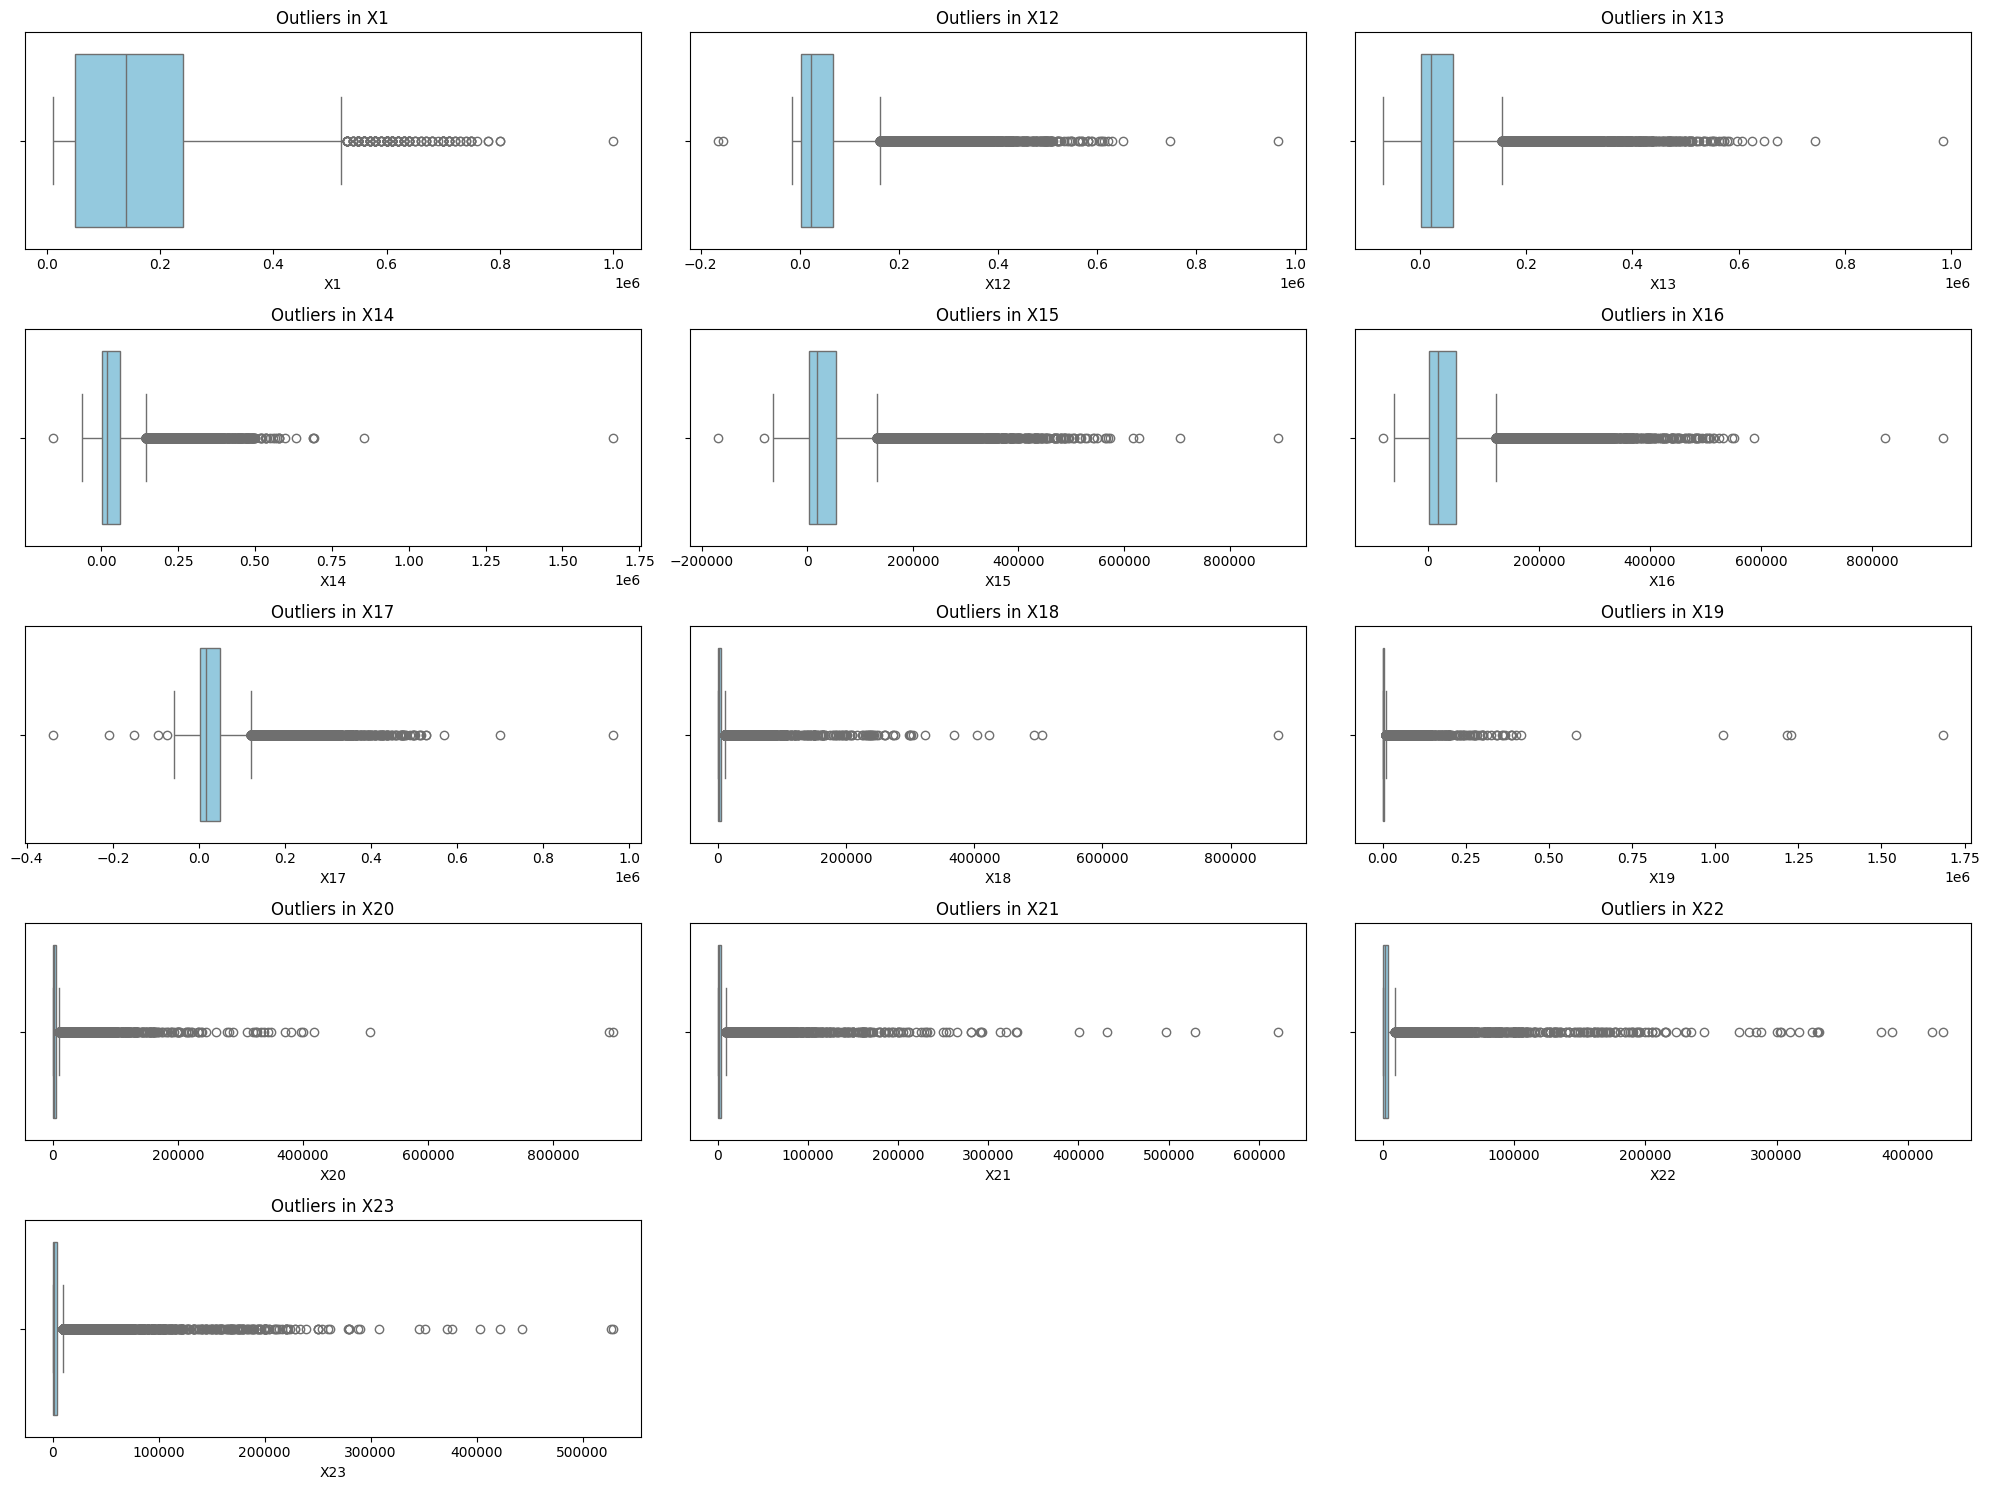

In [77]:
numeric_cols = ['X1','X12', 'X13', 'X14', 'X15', 'X16', 'X17', 
                'X18', 'X19', 'X20', 'X21', 'X22', 'X23']       #Select which column want to see the outliers of them

plt.figure(figsize=(20, 15))

for i, col in enumerate(numeric_cols):
    plt.subplot(5, 3, i+1) 
    sns.boxplot(x=df[col], color='skyblue')
    plt.title(f'Outliers in {col}')
    plt.tight_layout()


In [78]:
outlier_cols = [
    'X1',                        # LIMIT_BAL
    'X12', 'X13', 'X14', 'X15', 'X16', 'X17', # BILL_AMT1 to BILL_AMT6
    'X18', 'X19', 'X20', 'X21', 'X22', 'X23'  # PAY_AMT1 to PAY_AMT6
]
for col in outlier_cols:
        Q1 = df[col].quantile(0.25)
        Q3 = df[col].quantile(0.75)
        IQR = Q3 - Q1


        lower_bound = Q1 - 1.5 * IQR
        upper_bound = Q3 + 1.5 * IQR


        df[col] = df[col].clip(lower=lower_bound, upper=upper_bound)

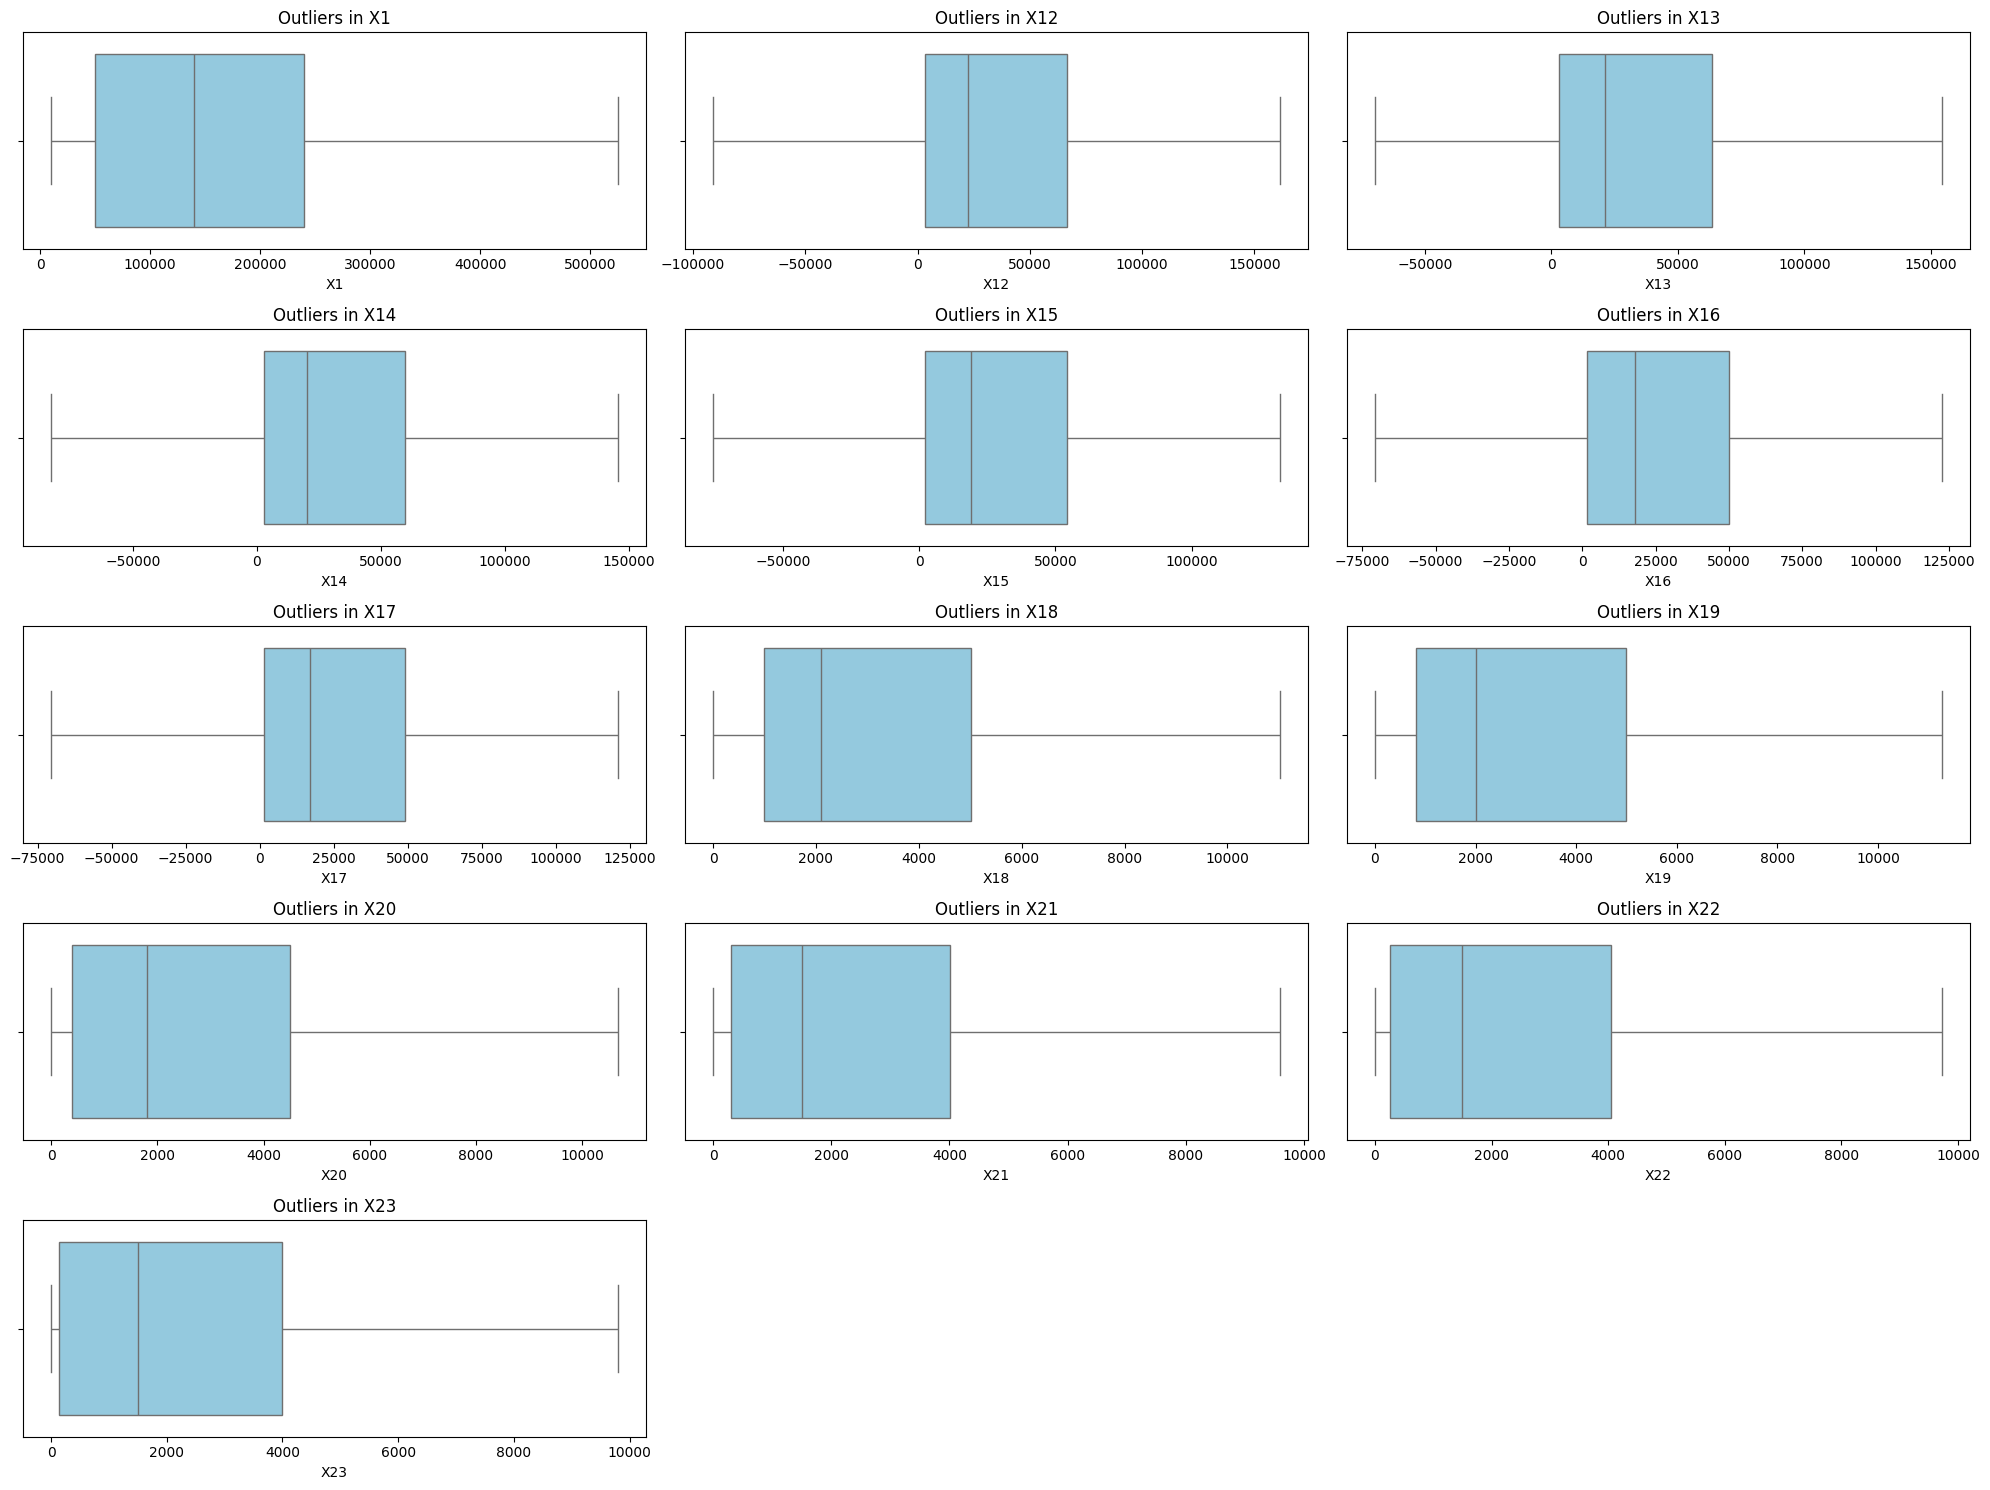

In [79]:


numeric_cols = ['X1', 'X12', 'X13', 'X14', 'X15', 'X16', 'X17', 
                'X18', 'X19', 'X20', 'X21', 'X22', 'X23']

plt.figure(figsize=(20, 15))

for i, col in enumerate(numeric_cols):
    plt.subplot(5, 3, i+1) 
    sns.boxplot(x=df[col], color='skyblue')
    plt.title(f'Outliers in {col}')
    plt.tight_layout()



Encoding

In [80]:


#Columns to be mapped
mapping_edu = {1: 'GradSchool', 2: 'University', 3: 'HighSchool', 4: 'Others'}
mapping_mar = {1: 'Married', 2: 'Single', 3: 'Others'}
mapping_sex = {1: 'Male', 2: 'Female'}

# Mapping of selected columns
df['X2'] = df['X2'].map(mapping_sex)
df['X3'] = df['X3'].map(mapping_edu)
df['X4'] = df['X4'].map(mapping_mar)

#Applying One Hot encoding
df = pd.get_dummies(df, columns=['X2', 'X3', 'X4'], prefix=['Sex', 'Edu', 'Mar'], drop_first=True,dtype=float)

#See the new columns values
print("Columns in Dataset now:")
print(df.columns)

Columns in Dataset now:
Index(['X1', 'X5', 'X6', 'X7', 'X8', 'X9', 'X10', 'X11', 'X12', 'X13', 'X14',
       'X15', 'X16', 'X17', 'X18', 'X19', 'X20', 'X21', 'X22', 'X23', 'Y',
       'Sex_Male', 'Edu_HighSchool', 'Edu_Others', 'Edu_University',
       'Mar_Others', 'Mar_Single'],
      dtype='object')


In [81]:
df.shape

(29601, 27)

In [82]:
df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 29601 entries, 1 to 30000
Data columns (total 27 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   X1              29601 non-null  float64
 1   X5              29601 non-null  float64
 2   X6              29601 non-null  float64
 3   X7              29601 non-null  float64
 4   X8              29601 non-null  float64
 5   X9              29601 non-null  float64
 6   X10             29601 non-null  float64
 7   X11             29601 non-null  float64
 8   X12             29601 non-null  float64
 9   X13             29601 non-null  float64
 10  X14             29601 non-null  float64
 11  X15             29601 non-null  float64
 12  X16             29601 non-null  float64
 13  X17             29601 non-null  float64
 14  X18             29601 non-null  float64
 15  X19             29601 non-null  float64
 16  X20             29601 non-null  float64
 17  X21             29601 non-null  floa

In [83]:
df.describe()

,X1,X5,X6,X7,X8,X9,X10,X11,X12,X13,...,X21,X22,X23,Y,Sex_Male,Edu_HighSchool,Edu_Others,Edu_University,Mar_Others,Mar_Single
count,29601.000000,29601.000000,29601.000000,29601.000000,29601.000000,29601.000000,29601.000000,29601.000000,29601.000000,29601.000000,...,29601.000000,29601.000000,29601.000000,29601.000000,29601.000000,29601.000000,29601.000000,29601.000000,29601.000000,29601.000000
mean,167028.940914,35.464072,-0.014932,-0.131313,-0.163440,-0.218303,-0.263978,-0.287558,44004.554643,42124.003344,...,2718.360630,2735.957907,2713.009324,0.223134,0.396811,0.164623,0.004155,0.473768,0.010743,0.533968
std,128195.491191,9.213243,1.124503,1.199642,1.199793,1.172220,1.136217,1.152206,50946.023388,48909.338691,...,3073.590945,3098.985600,3124.167065,0.416355,0.489244,0.370846,0.064328,0.499320,0.103091,0.498853
min,10000.000000,21.000000,-2.000000,-2.000000,-2.000000,-2.000000,-2.000000,-2.000000,-91114.500000,-69777.000000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
25%,50000.000000,28.000000,-1.000000,-1.000000,-1.000000,-1.000000,-1.000000,-1.000000,3528.000000,2970.000000,...,298.000000,259.000000,138.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
50%,140000.000000,34.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,22259.000000,21050.000000,...,1500.000000,1500.000000,1500.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,1.000000
75%,240000.000000,41.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,66623.000000,63497.000000,...,4014.000000,4042.000000,4000.000000,0.000000,1.000000,0.000000,0.000000,1.000000,0.000000,1.000000
max,525000.000000,79.000000,8.000000,8.000000,8.000000,8.000000,8.000000,8.000000,161265.500000,154287.500000,...,9588.000000,9716.500000,9793.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000


In [84]:
#dataset size
#no missing values

In [85]:
#### Class imbalance
df["Y"].value_counts()

Y
0.0    22996
1.0     6605
Name: count, dtype: int64

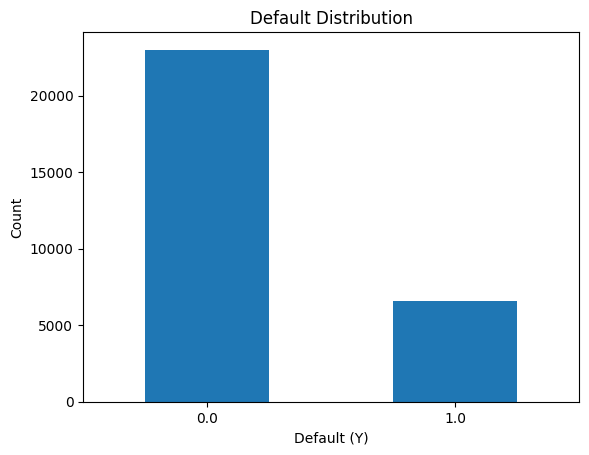

In [86]:
df["Y"].value_counts().plot(kind="bar")

plt.title("Default Distribution")
plt.xlabel("Default (Y)")
plt.ylabel("Count")
plt.xticks(rotation=0)
plt.show()

In [87]:
#class imbalance 22.32% y = 1 vs 77.68% y = 0 (approx)
#The target variable is imbalanced, with approximately 77.68% of clients not defaulting and 22.32% defaulting.
#This imbalance may affect model performance, as models could become biased toward the majority class

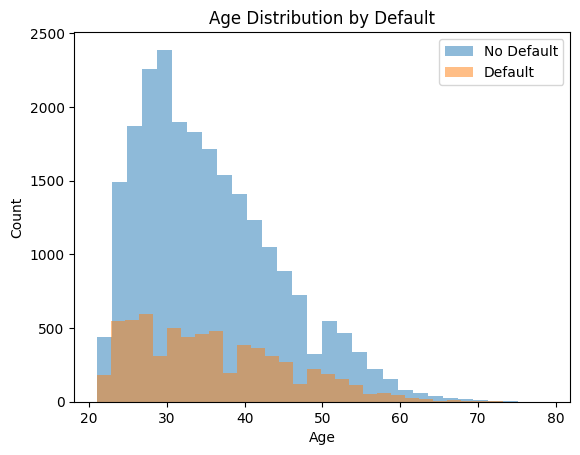

In [88]:
#### Age distribution by default status
plt.hist(df[df["Y"] == 0]["X5"], bins=30, alpha=0.5, label="No Default")
plt.hist(df[df["Y"] == 1]["X5"], bins=30, alpha=0.5, label="Default")

plt.title("Age Distribution by Default")
plt.xlabel("Age")
plt.ylabel("Count")
plt.legend()
plt.show()

In [89]:
#Most users are young: The biggest group of people using
#                      credit cards is between 25 and 35 years old.

#Defaulting is spread out: People of all ages default,
#                          but because there are more young people in the dataset,
#                          you see more orange "Default" bars in the younger section.

#Older users are fewer: As people get older (past age 50),
#                       the number of both "Good Payers" and "Defaulters" drops significantly.

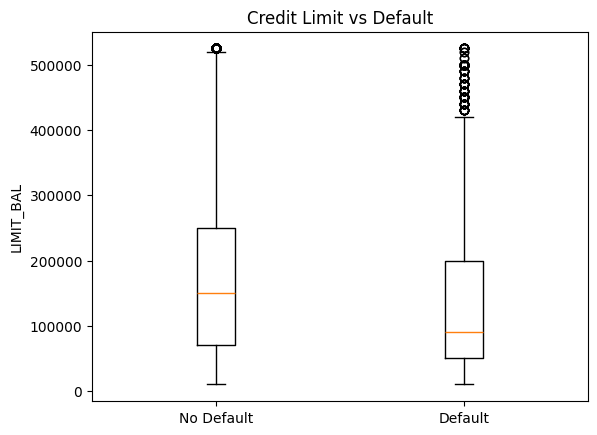

In [90]:
### Credit limit distribution by default status
#Clients with lower credit limits are more likely to default.
data_0 = df[df["Y"] == 0]["X1"]
data_1 = df[df["Y"] == 1]["X1"]

plt.boxplot([data_0, data_1], tick_labels=["No Default", "Default"])

plt.title("Credit Limit vs Default")
plt.ylabel("LIMIT_BAL")
plt.show()


In [91]:
#Clients who did not default tend to have higher credit limits compared to those who defaulted.
#This suggests that customers with higher financial trust from the bank are less likely to fail in repayment
#The boxplot shows that default behavior is associated with lower credit limits,
#while non-default clients tend to have higher and more stable credit limits.
#Additionally, the presence of outliers in the default group indicates 
#higher variability in financial behavior among defaulters.

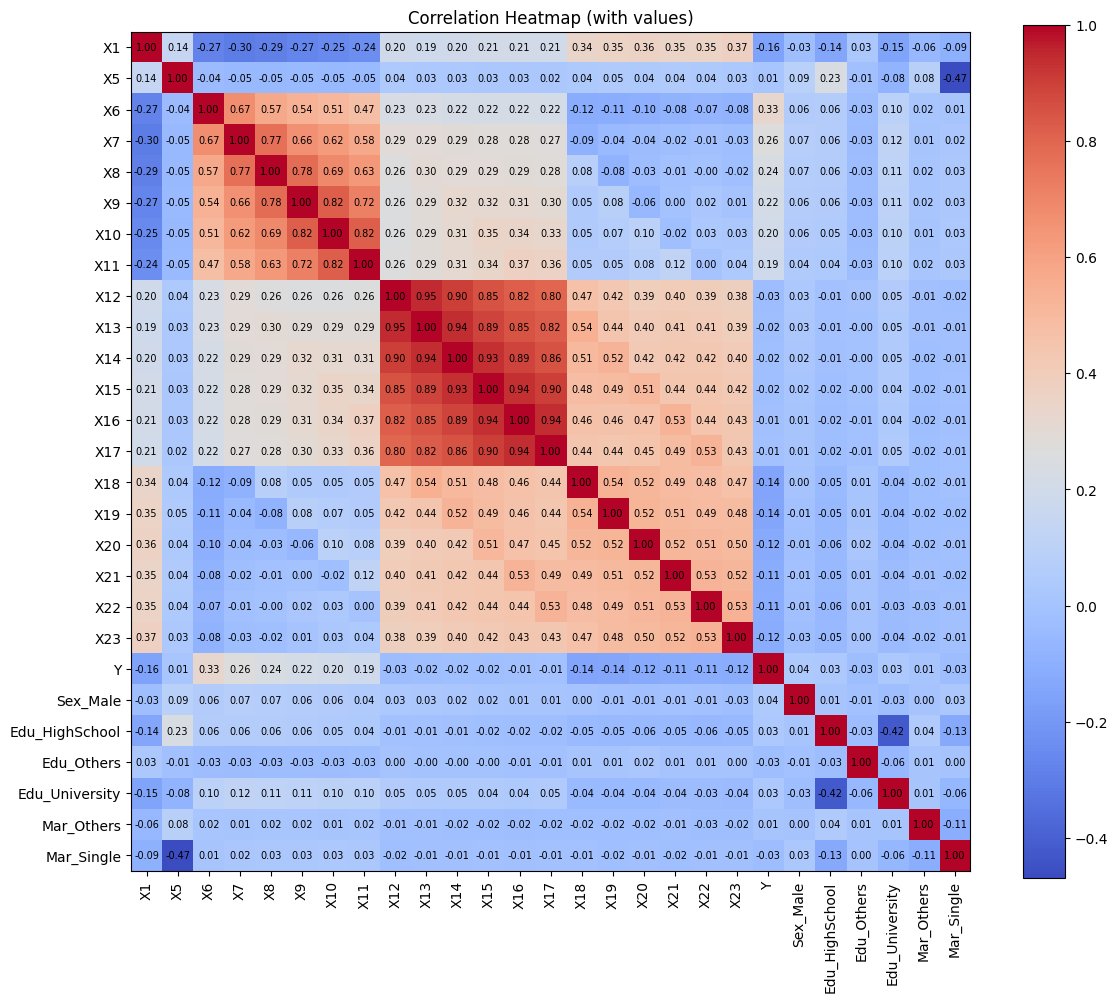

In [92]:
#Correlation heatmap(before feature engineering)


corr = df.corr()

plt.figure(figsize=(12,10))
plt.imshow(corr, cmap='coolwarm', interpolation='nearest')
plt.colorbar()


plt.xticks(ticks=np.arange(len(corr.columns)), labels=corr.columns, rotation=90)
plt.yticks(ticks=np.arange(len(corr.columns)), labels=corr.columns)


for i in range(len(corr.columns)):
    for j in range(len(corr.columns)):
        plt.text(j, i, f"{corr.iloc[i, j]:.2f}",
                 ha="center", va="center",
                 color="black", fontsize=7)

plt.title("Correlation Heatmap (with values)")
plt.tight_layout()
plt.show()

In [93]:
#The heatmap shows the relationships between features,
#      where bill amounts and payment amounts are highly correlated with each other.

#This indicates potential redundancy among these variables as they capture similar financial behavior,
#      BILL_AMT1 → BILL_AMT6
#      or PAY_AMT1 → PAY_AMT6
#      are highly correlated,
#      df["TOTAL_BILL"] = df[["X12","X13","X14","X15","X16","X17"]].sum(axis=1)
#      df["TOTAL_PAY"] = df[["X18","X19","X20","X21","X22","X23"]].sum(axis=1)

#Additionally, financial features show stronger relationships with the target variable compared to
#  demographic features, suggesting they are more important for predicting default.


#A new feature (TOTAL_DELAY) was created to capture the frequency of late payments by
#    counting the number of months with delayed repayment.
#This summarizes the client's repayment behavior in a single variable and helps improve interpretability.


Adding new features 
#feature engineering

In [94]:
#Total payment 
pay_cols = ["X18","X19","X20","X21","X22","X23"]
df["TOTAL_PAY"] = df[pay_cols].sum(axis=1)
#Total bill
bill_cols = ["X12","X13","X14","X15","X16","X17"]
df["TOTAL_BILL"] = df[bill_cols].sum(axis=1)
#Total delay
pay_cols = ["X6","X7","X8","X9","X10","X11"]
df["TOTAL_DELAY"] = (df[pay_cols] > 0).sum(axis=1)


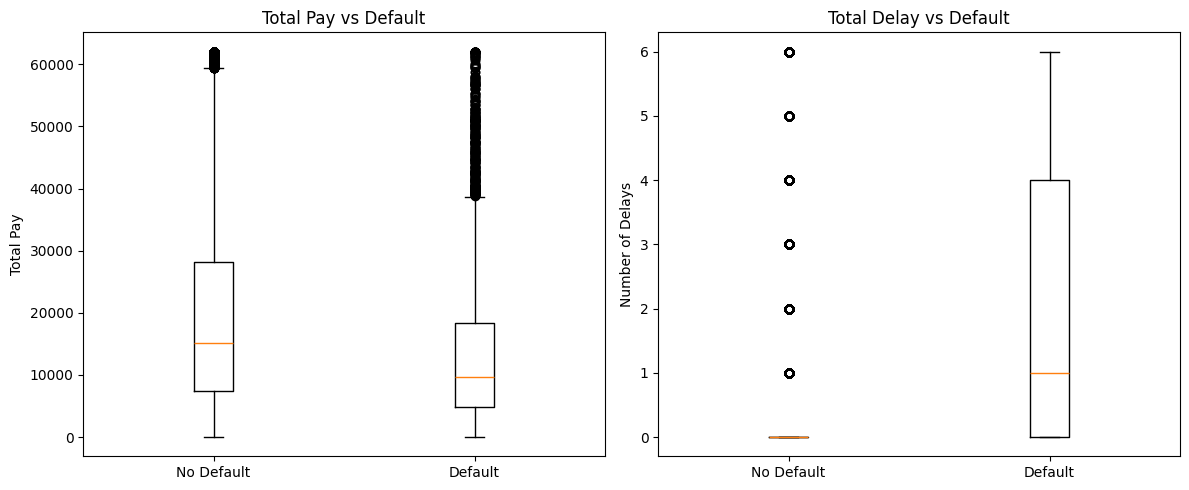

In [95]:
import matplotlib.pyplot as plt

fig, axes = plt.subplots(1, 2, figsize=(12, 5))

# 1. TOTAL_PAY
data_0_pay = df[df["Y"] == 0]["TOTAL_PAY"]
data_1_pay = df[df["Y"] == 1]["TOTAL_PAY"]

axes[0].boxplot([data_0_pay, data_1_pay], tick_labels=["No Default", "Default"])
axes[0].set_title("Total Pay vs Default")
axes[0].set_ylabel("Total Pay")

# 2. TOTAL_DELAY
data_0_delay = df[df["Y"] == 0]["TOTAL_DELAY"]
data_1_delay = df[df["Y"] == 1]["TOTAL_DELAY"]

axes[1].boxplot([data_0_delay, data_1_delay], tick_labels=["No Default", "Default"])
axes[1].set_title("Total Delay vs Default")
axes[1].set_ylabel("Number of Delays")

plt.tight_layout()
plt.show()

In [96]:
#Total Delay vs Default:

#Reliable people stay on time: For the "No Default" group, the middle line is at zero.
#                             This means most people who don't default never miss a payment.

#Delays lead to trouble: The "Default" group has a much higher box,
#                        showing they frequently have 1 to 4 months of delays.

#The clearest sign: If someone starts having even one or two late payments,
#                   they are much more likely to fall into the "Default" category than someone who stays at zero.


In [97]:
#Total Pay vs Default:

#Good payers pay more: People who don't default (the "No Default" box)
#                      generally make larger monthly payments than those who do default.

#Low payments are a warning: The "Default" group has a lower middle line
#                             meaning they are usually paying smaller amounts toward their bills.

#Big spenders exist in both: Even some people who pay very large amounts (the dots at the very top)
#                  still end up defaulting, likely because their total debt is even higher than their payments.

After completing my analysis, I suggest building the model using the following features:
['X1', 'X6', 'X7', 'X8', 'X9', 'X10', 'X11', 'TOTAL_BILL', 'TOTAL_PAY', 'TOTAL_DELAY'].

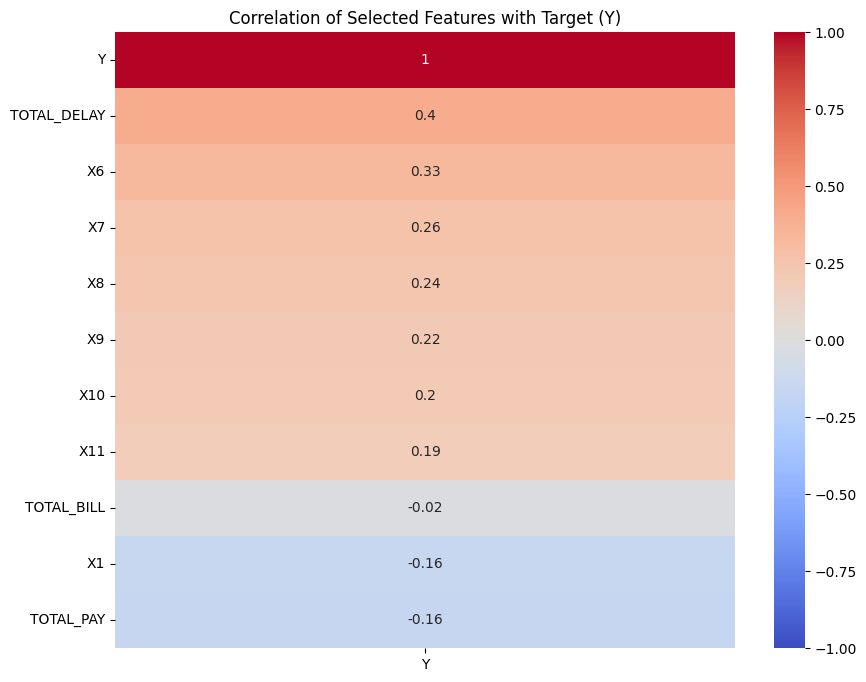

In [98]:
#Correlation heatmap(after feature engineering & feture selection)
import seaborn as sns
import matplotlib.pyplot as plt

features = ['X1', 'X6', 'X7', 'X8', 'X9', 'X10', 'X11',
            "TOTAL_BILL", "TOTAL_PAY", "TOTAL_DELAY", "Y"]

subset = df[features]

corr = subset.corr()

plt.figure(figsize=(10, 8))
sns.heatmap(corr[['Y']].sort_values(by='Y', ascending=False),
            annot=True, cmap='coolwarm', vmin=-1, vmax=1)

plt.title("Correlation of Selected Features with Target (Y)")
plt.show()

Feature Scaling

In [99]:
from sklearn.preprocessing import StandardScaler
scaler = StandardScaler()
                                          #Feature Scaling from -3 to 3
cols_to_scale = ['X1', 'X5', 'X6', 'X7', 'X8', 'X9', 'X10', 'X11', 'X12', 'X13', 'X14',
       'X15', 'X16', 'X17', 'X18', 'X19', 'X20', 'X21', 'X22', 'X23', "TOTAL_BILL", "TOTAL_PAY"]

df[cols_to_scale] = scaler.fit_transform(df[cols_to_scale])
print(df.head())


         X1        X5        X6        X7        X8        X9       X10  \
1 -1.146931 -1.244325  1.791873  1.776654 -0.697265 -0.666863 -1.527923   
2 -0.366860 -1.027242 -0.876018  1.776654  0.136226  0.186234  0.232334   
3 -0.600881 -0.158912  0.013279  0.109462  0.136226  0.186234  0.232334   
4 -0.912910  0.166712  0.013279  0.109462  0.136226  0.186234  0.232334   
5 -0.912910  2.337536 -0.876018  0.109462 -0.697265  0.186234  0.232334   

        X11       X12       X13  ...    Y  Sex_Male  Edu_HighSchool  \
1 -1.486255 -0.786955 -0.797857  ...  1.0       0.0             0.0   
2  1.985406 -0.811118 -0.826012  ...  1.0       0.0             0.0   
3  0.249576 -0.289832 -0.574481  ...  0.0       0.0             0.0   
4  0.249576  0.058601  0.124907  ...  0.0       0.0             0.0   
5  0.249576 -0.694621 -0.745351  ...  0.0       1.0             0.0   

   Edu_Others  Edu_University  Mar_Others  Mar_Single  TOTAL_PAY  TOTAL_BILL  \
1         0.0             1.0         0.0 

In [100]:
#separating the target variable (Y) from the features (X)
y = df["Y"]
X = df[['X1', 'X6', 'X7', 'X8', 'X9', 'X10', 'X11'
        , "TOTAL_PAY", "TOTAL_DELAY"]]

In [101]:
from sklearn.model_selection import StratifiedKFold, train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import classification_report, confusion_matrix, roc_auc_score
from sklearn.pipeline import Pipeline
from sklearn.model_selection import GridSearchCV
from sklearn.model_selection import KFold , StratifiedKFold


# Splitting the dataset into training and testing sets, with stratification to maintain class balance in both sets.
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42,stratify=y)

# # Creating a pipeline with logistic regression and setting up a grid search for hyperparameter tuning.
pipeline = Pipeline([
    ('model', LogisticRegression(random_state=42,class_weight='balanced'))
])
param_grid = {
    'model__max_iter': [1000, 10000, 100000],
    'model__C': [0.01, 0.1, 1, 10, 100],
    'model__penalty': ['l1', 'l2'],
    'model__solver': ['saga']
    }

# used CV with 10 splits and grid search to find the best hyperparameters for the logistic regression model, optimizing for F1 score.
cv = StratifiedKFold(n_splits=10, shuffle=True, random_state=42)
grid_search = GridSearchCV(estimator=pipeline, param_grid=param_grid, cv=cv, scoring='f1')
grid_search.fit(X_train, y_train)



GridSearchCV(cv=StratifiedKFold(n_splits=10, random_state=42, shuffle=True),
             estimator=Pipeline(steps=[('model',
                                        LogisticRegression(class_weight='balanced',
                                                           random_state=42))]),
             param_grid={'model__C': [0.01, 0.1, 1, 10, 100],
                         'model__max_iter': [1000, 10000, 100000],
                         'model__penalty': ['l1', 'l2'],
                         'model__solver': ['saga']},
             scoring='f1')

Best Parameters: {'model__C': 0.01, 'model__max_iter': 1000, 'model__penalty': 'l1', 'model__solver': 'saga'}

Classification Report:
               precision    recall  f1-score   support

         0.0       0.87      0.85      0.86      4600
         1.0       0.51      0.54      0.52      1321

    accuracy                           0.78      5921
   macro avg       0.69      0.69      0.69      5921
weighted avg       0.79      0.78      0.78      5921

ROC-AUC Score: 0.7522
F1-Score: 0.5227
Accuracy: 0.7794
Precision: 0.5053
Recall: 0.5413
Class distribution in test set:
Y
0.0    4600
1.0    1321
Name: count, dtype: int64


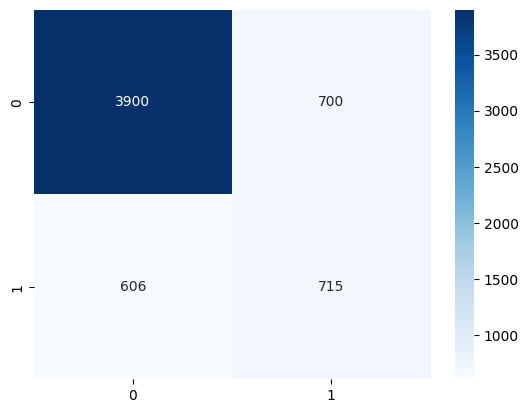

In [113]:
# # Get the best model
from sklearn.metrics import classification_report, roc_auc_score,confusion_matrix,f1_score,accuracy_score,precision_score,recall_score
best_model = grid_search.best_estimator_

# Predict and Evaluate
threshold = 0.57
y_proba = best_model.predict_proba(X_test)[:, 1]
y_pred = (y_proba >= threshold).astype(int)

print(f"Best Parameters: {grid_search.best_params_}")
print("\nClassification Report:\n", classification_report(y_test, y_pred))
print(f"ROC-AUC Score: {roc_auc_score(y_test, y_proba):.4f}")

cm = confusion_matrix(y_test, y_pred)
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')
print(f"F1-Score: {f1_score(y_test, y_pred):.4f}")
print(f"Accuracy: {accuracy_score(y_test, y_pred):.4f}")
print(f"Precision: {precision_score(y_test, y_pred):.4f}")
print(f"Recall: {recall_score(y_test, y_pred):.4f}")

#number of samples in each class
print("Class distribution in test set:")
print(y_test.value_counts())



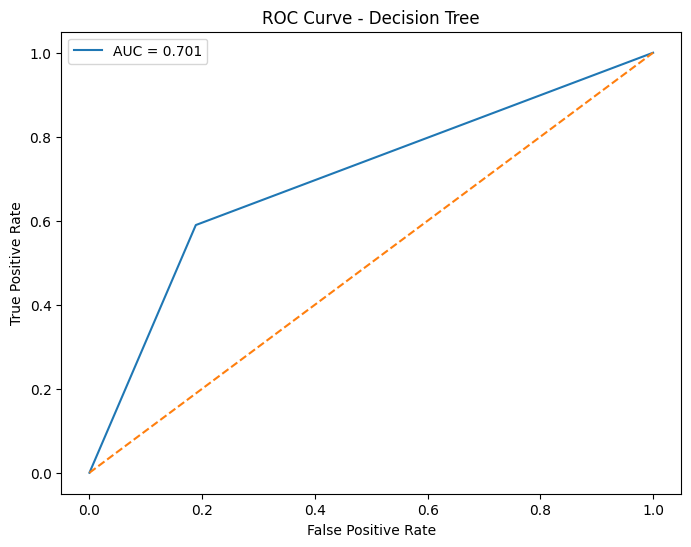

In [103]:
import matplotlib.pyplot as plt
from sklearn.metrics import roc_curve , roc_auc_score

y_pred_probs = best_model.predict(X_test)
y_pred = (y_pred_probs > 0.7).astype("int32")


fpr, tpr, thresholds = roc_curve(y_test, y_pred)
# AUC score
auc_score = roc_auc_score(y_test, y_pred)

# Plot
plt.figure(figsize=(8,6))

plt.plot(fpr, tpr, label=f'AUC = {auc_score:.3f}')

# Random classifier line
plt.plot([0, 1], [0, 1], linestyle='--')

plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve - Decision Tree")

plt.legend()

In [104]:

import tensorflow as tf
from keras import layers, metrics
from keras.models import Sequential
from keras.callbacks import EarlyStopping

# 1. define model layers and activation function , and adding batchnormalization and dropout to make data converge better and avoid overfiting
model_nn = Sequential([
    layers.Dense(128, activation='relu', input_shape=(9,)), 
    layers.BatchNormalization(), 
    layers.Dropout(0.3),        
    layers.Dense(64, activation='relu'),
    layers.BatchNormalization(),
    layers.Dropout(0.3),
    layers.Dense(1, activation='sigmoid')
])

#2.compiling model with adam optimizer and watching accuracy,percision , recall and AUC metrics
model_nn.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=1e-3),
    loss='binary_crossentropy',
    metrics=[
        metrics.BinaryAccuracy(name='accuracy'),
        metrics.AUC(name='auc'),
        metrics.Precision(name='precision'),
        metrics.Recall(name='recall'),
        metrics.AUC(name='prc', curve='PR')
    ]
)



# 3. adjusting weights to count for class imbalance , training for 150 epoch , validation and history to visualize later
strong_class_weight = {0: 0.8, 1: 4}
history = model_nn.fit(
    X_train, y_train, 
    validation_split=0.2, 
    epochs=150, 
    class_weight=strong_class_weight
)

Epoch 1/150


d:\anaconda\Lib\site-packages\keras\src\layers\core\dense.py:92: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


592/592 ━━━━━━━━━━━━━━━━━━━━ 4s 4ms/step - accuracy: 0.6170 - auc: 0.7190 - loss: 0.9592 - prc: 0.4452 - precision: 0.3311 - recall: 0.7190 - val_accuracy: 0.6427 - val_auc: 0.7736 - val_loss: 0.6640 - val_prc: 0.5467 - val_precision: 0.3716 - val_recall: 0.7807
Epoch 2/150
592/592 ━━━━━━━━━━━━━━━━━━━━ 2s 3ms/step - accuracy: 0.6418 - auc: 0.7487 - loss: 0.8820 - prc: 0.4863 - precision: 0.3524 - recall: 0.7419 - val_accuracy: 0.6962 - val_auc: 0.7761 - val_loss: 0.6432 - val_prc: 0.5521 - val_precision: 0.4108 - val_recall: 0.7125
Epoch 3/150
592/592 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - accuracy: 0.6474 - auc: 0.7542 - loss: 0.8697 - prc: 0.4977 - precision: 0.3567 - recall: 0.7422 - val_accuracy: 0.6717 - val_auc: 0.7778 - val_loss: 0.6447 - val_prc: 0.5546 - val_precision: 0.3917 - val_recall: 0.7507
Epoch 4/150
592/592 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - accuracy: 0.6549 - auc: 0.7645 - loss: 0.8565 - prc: 0.5077 - precision: 0.3637 - recall: 0.7498 - val_accuracy: 0.6658 - val_auc: 0

186/186 ━━━━━━━━━━━━━━━━━━━━ 0s 992us/step
--- Credit Default Model Metrics ---
              precision    recall  f1-score   support

  No Default       0.87      0.86      0.86      4600
     Default       0.52      0.54      0.53      1321

    accuracy                           0.79      5921
   macro avg       0.69      0.70      0.70      5921
weighted avg       0.79      0.79      0.79      5921



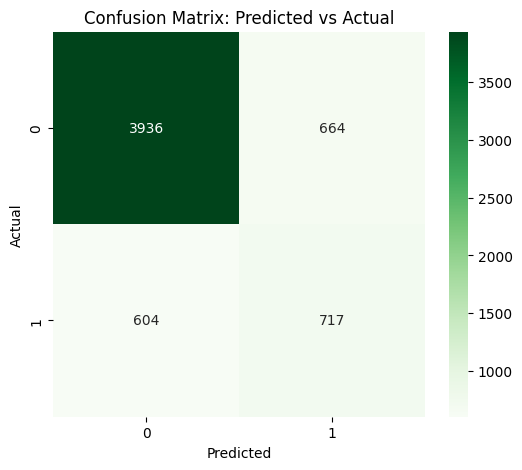

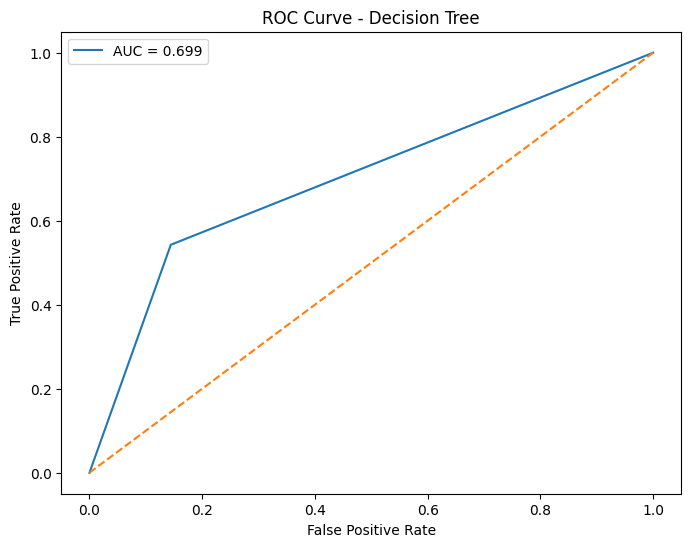

In [ ]:
from sklearn.metrics import classification_report, confusion_matrix, f1_score
import seaborn as sns
import matplotlib.pyplot as plt
import matplotlib.pyplot as plt
from sklearn.metrics import roc_curve , roc_auc_score

# 1. Get predictions on the test set
y_pred_probs = model_nn.predict(X_test)
y_pred = (y_pred_probs > 0.68).astype("int32")

# 2. Print the Core Metrics
print("--- Credit Default Model Metrics ---")
print(classification_report(y_test, y_pred, target_names=['No Default', 'Default']))
# 3. Plot the Confusion Matrix
cm = confusion_matrix(y_test, y_pred)
plt.figure(figsize=(6, 5))
sns.heatmap(cm, annot=True, fmt='d', cmap='Greens', 
            xticklabels=['0', '1'], 
            yticklabels=['0', '1'])
plt.title('Confusion Matrix: Predicted vs Actual')
plt.ylabel('Actual')
plt.xlabel('Predicted')
plt.show()

fpr, tpr, thresholds = roc_curve(y_test, y_pred)
# AUC score
auc_score = roc_auc_score(y_test, y_pred)

# Plot
plt.figure(figsize=(8,6))

plt.plot(fpr, tpr, label=f'AUC = {auc_score:.3f}')

# Random classifier line
plt.plot([0, 1], [0, 1], linestyle='--')

plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve - neural network")

plt.legend()

{'ccp_alpha': 0.0001, 'class_weight': {0: 1, 1: 3}, 'criterion': 'gini', 'max_depth': 10, 'max_features': 'sqrt', 'min_samples_leaf': 20, 'min_samples_split': 10}
0.5430801072914928


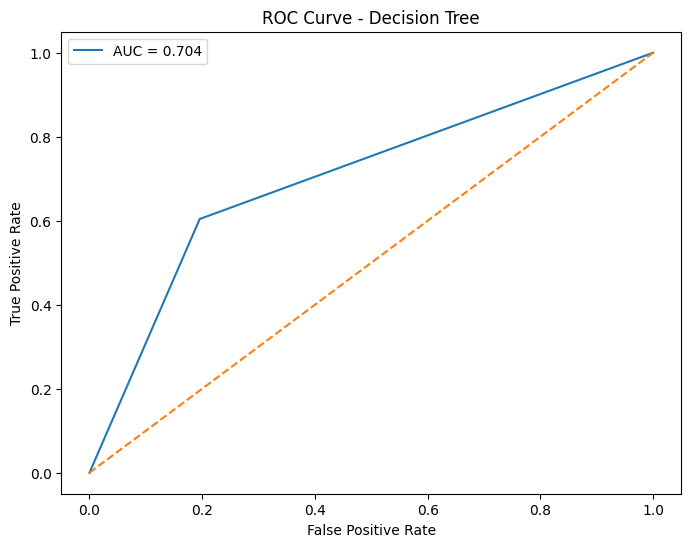

--- Credit Default Model Metrics ---
              precision    recall  f1-score   support

  No Default       0.88      0.80      0.84      4600
     Default       0.47      0.60      0.53      1321

    accuracy                           0.76      5921
   macro avg       0.67      0.70      0.68      5921
weighted avg       0.79      0.76      0.77      5921



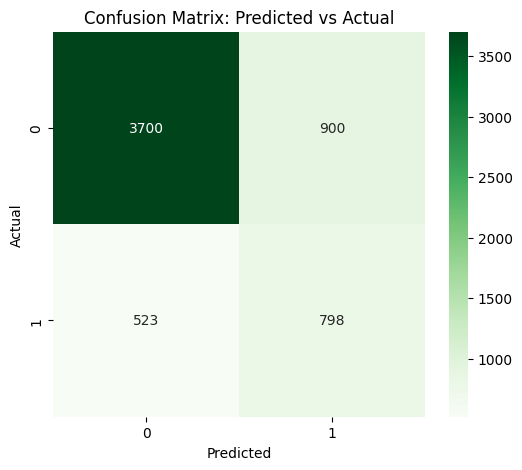

In [ ]:
from sklearn.tree import DecisionTreeClassifier
from sklearn.model_selection import GridSearchCV
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import roc_curve

params = {
    'criterion': ['gini', 'entropy'],
    'max_depth': [4, 6, 8, 10, 12],
    'min_samples_split': [10, 20, 50, 100],
    'min_samples_leaf': [2, 5, 10, 20],
    'max_features': [None, 'sqrt'],
    'ccp_alpha': [0.0, 0.0001, 0.001],
    'class_weight': [
        None,
        'balanced',
        {0:1, 1:2},
        {0:1, 1:3},
    ]
}

grid = GridSearchCV(
    DecisionTreeClassifier(
        class_weight='balanced',
        random_state=42
    ),
    params,
    scoring='f1',
    cv=5,
)

grid.fit(X_train, y_train)

print(grid.best_params_)
print(grid.best_score_)

y_pred = grid.predict(X_test)
fpr, tpr, thresholds = roc_curve(y_test, y_pred)
auc_score = roc_auc_score(y_test, y_pred)


plt.figure(figsize=(8,6))

plt.plot(fpr, tpr, label=f'AUC = {auc_score:.3f}')

plt.plot([0, 1], [0, 1], linestyle='--')

plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve - Decision Tree")
plt.legend()
plt.show()





# 2. Print the Core Metrics
print("--- Credit Default Model Metrics ---")
print(classification_report(y_test, y_pred, target_names=['No Default', 'Default']))
# 3. Plot the Confusion Matrix
cm = confusion_matrix(y_test, y_pred)
plt.figure(figsize=(6, 5))
sns.heatmap(cm, annot=True, fmt='d', cmap='Greens', 
            xticklabels=['0', '1'], 
            yticklabels=['0', '1'])
plt.title('Confusion Matrix: Predicted vs Actual')
plt.ylabel('Actual')
plt.xlabel('Predicted')
plt.show()